In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv


In [2]:
# ======================================================
# Import Required Libraries
# ======================================================

# This notebook uses the Kaggle Python environment, which comes with
# most popular data science and machine learning libraries pre-installed.

import warnings
warnings.filterwarnings("ignore")

# Numerical and Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OrdinalEncoder
)

# Machine Learning Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display all columns while exploring the dataset
pd.set_option("display.max_columns", None)

print("=" * 60)
print("All Required Libraries Imported Successfully")
print("=" * 60)

All Required Libraries Imported Successfully


# 📂 Load Training & Testing Datasets

Before building any machine learning model, we first load the **training** and **testing** datasets into our notebook.

- **Training Dataset** → Used to teach the model patterns in historical flight prices.
- **Testing Dataset** → Used to predict ticket prices for unseen flights.

This is the starting point of our analysis, where we verify that both datasets are loaded successfully and inspect a few sample records.

In [3]:
# ======================================================
# Load Training and Testing Datasets
# ======================================================

train_df = pd.read_csv(
    "/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv"
)

test_df = pd.read_csv(
    "/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv"
)

print("=" * 60)
print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)
print("=" * 60)

display(train_df.head())

Training Dataset Shape : (40000, 12)
Testing Dataset Shape  : (10000, 11)


,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584


# 🔍 Understanding the Dataset Structure

Not every column stores the same type of information.

Some columns contain **numbers** (such as flight duration or ticket price), while others contain **categories** (such as airline or source city).

Knowing the data type of each feature helps us decide:
- 📊 Which columns can be analyzed statistically.
- 🔧 Which columns need encoding before model training.
- ⚙️ Which preprocessing techniques should be applied.

Understanding the dataset structure is an important first step before any cleaning or modeling.

In [4]:
# ======================================================
# Identify Data Types of Different Columns
# ======================================================

print("=" * 60)
print("Training Dataset Information")
print("=" * 60)

train_df.info()

print("\n" + "=" * 60)
print("Column Data Types")
print("=" * 60)

display(train_df.dtypes.to_frame(name="Data Type"))

Training Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB

Column Data Types


,Data Type
id,int64
airline,object
flight,object
source,object
departure,object
stops,object
arrival,object
destination,object
class,object
duration,float64


# 📈 Exploring Numerical Features

Before building a predictive model, it is important to understand the overall characteristics of the numerical data.

Here we calculate statistics such as:

- 📌 Minimum value
- 📌 Maximum value
- 📌 Mean
- 📌 Median
- 📌 Standard deviation

These statistics provide a quick overview of the data distribution and help identify unusual values that may require further investigation.

In [5]:
# ======================================================
# Descriptive Statistics of Numerical Columns
# ======================================================

print("=" * 60)
print("Summary Statistics of Numerical Features")
print("=" * 60)

display(train_df.describe().T)

print("\n" + "=" * 60)
print("Median of Numerical Features")
print("=" * 60)

display(train_df.median(numeric_only=True).to_frame(name="Median"))

Summary Statistics of Numerical Features


,count,mean,std,min,25%,50%,75%,max
id,40000.0,19999.500000,11547.149720,0.00,9999.75,19999.50,29999.25,39999.00
duration,36987.0,12.004088,7.108063,0.83,6.67,11.08,15.92,47.08
days_left,35562.0,26.197936,13.469232,1.00,15.00,26.00,38.00,49.00
price,40000.0,20801.490250,22729.148420,1105.00,4687.00,7353.00,42521.00,114704.00



Median of Numerical Features


,Median
id,19999.50
duration,11.08
days_left,26.00
price,7353.00


## 📌 Key Insights from Summary Statistics

A quick look at the numerical features helps us understand the overall characteristics of the dataset.

Some observations include:

- ✈️ Flight durations vary considerably, indicating both short domestic and long connecting flights.
- 📅 The number of days left before departure spans a wide range, suggesting customers book tickets at different times.
- 💰 Ticket prices also show large variation, which is expected because airfare depends on several factors such as airline, travel class, duration, and booking time.

These observations confirm that the dataset contains sufficient variation for building a meaningful prediction model.

# 🧩 Identifying Missing Values

Real-world datasets are rarely complete. Some observations may have missing information due to data collection or recording issues.

In this step, we identify:

- Number of missing values
- Percentage of missing values in each column

This helps us understand the quality of the dataset before applying any preprocessing techniques.

In [6]:
# ======================================================
# Identify Missing Values
# ======================================================

missing_values = pd.DataFrame({
    "Missing Values": train_df.isnull().sum(),
    "Percentage": (train_df.isnull().sum() / len(train_df)) * 100
})

missing_values = missing_values[missing_values["Missing Values"] > 0]

print("=" * 60)
print("Missing Value Summary")
print("=" * 60)

display(missing_values.sort_values("Missing Values", ascending=False))

Missing Value Summary


,Missing Values,Percentage
departure,4792,11.9800
airline,4613,11.5325
days_left,4438,11.0950
duration,3013,7.5325
stops,2319,5.7975


## 🔎 Observation

The dataset contains missing values in a few features.

Instead of removing these records, we preserve valuable information by filling missing numerical values with the **median** and categorical values with the **most frequent category (mode)**.

This ensures that the dataset remains complete without unnecessarily reducing its size.

# 🛠️ Handling Missing Values

Machine learning models cannot work efficiently with incomplete data.

To preserve as much information as possible:

- 📌 Numerical features are filled using the **median**, which is less affected by extreme values.
- 📌 Categorical features are filled using the **most frequent category (mode)**.

This approach keeps the dataset complete while minimizing unnecessary bias.

In [7]:
# ======================================================
# Handle Missing Values
# ======================================================

train_df["duration"] = train_df["duration"].fillna(
    train_df["duration"].median()
)

test_df["duration"] = test_df["duration"].fillna(
    test_df["duration"].median()
)

categorical_columns = [
    "airline",
    "departure",
    "stops"
]

for col in categorical_columns:
    train_df[col] = train_df[col].fillna(
        train_df[col].mode()[0]
    )

    test_df[col] = test_df[col].fillna(
        test_df[col].mode()[0]
    )

train_df["days_left"] = train_df["days_left"].fillna(
    train_df["days_left"].median()
)

test_df["days_left"] = test_df["days_left"].fillna(
    test_df["days_left"].median()
)

print("=" * 60)
print("Remaining Missing Values")
print("=" * 60)

display(train_df.isnull().sum())

Remaining Missing Values


id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
price          0
dtype: int64

## ✅ Data Cleaning Complete

All missing values have now been handled successfully.

Having a complete dataset ensures that machine learning algorithms can process every observation without errors, making the training process more reliable.

# 📄 Checking for Duplicate Records

Duplicate records can unintentionally give more importance to certain observations and may affect the model's learning.

Here, we check whether duplicate rows exist.

If duplicates are found, they are removed to ensure that every observation contributes fairly to the model.

In [8]:
# ======================================================
# Identify and Handle Duplicate Records
# ======================================================

duplicates = train_df.duplicated().sum()

print("=" * 60)
print(f"Duplicate Rows Found : {duplicates}")
print("=" * 60)

if duplicates > 0:
    train_df.drop_duplicates(inplace=True)
    print("Duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

Duplicate Rows Found : 0
No duplicate rows found.


## ✅ Observation

No duplicate records were found in the dataset.

This indicates that each flight record is unique and no additional cleaning was required at this stage.

# 📦 Detecting Outliers

Outliers are observations that differ significantly from the majority of the data.

We visualize numerical features using **boxplots** to identify these extreme values.

Rather than removing them immediately, we first examine whether they represent genuine flight information or data entry errors.

For airline pricing, unusually high ticket prices often correspond to **Business Class** or last-minute bookings, so such values may still be valid.

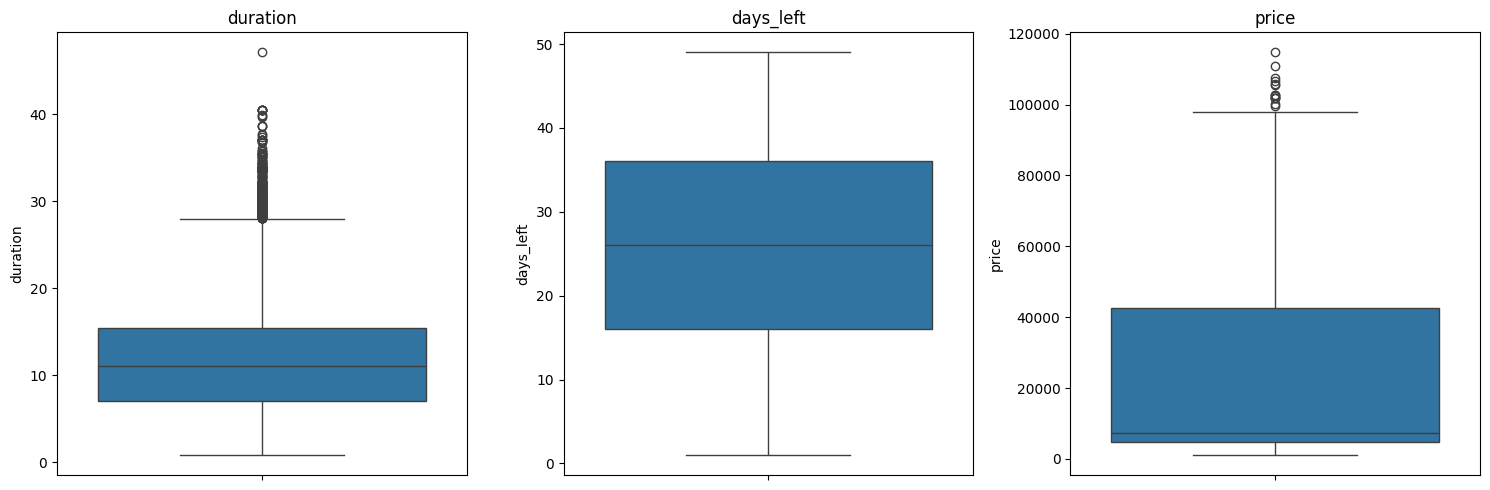

In [9]:
# ======================================================
# Detect Outliers using Boxplots
# ======================================================

numerical_features = [
    "duration",
    "days_left",
    "price"
]

plt.figure(figsize=(15,5))

for i, column in enumerate(numerical_features, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=train_df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

## 📦 Observation

The boxplots indicate the presence of several extreme values, particularly in **ticket prices**.

These values are expected in airline pricing because premium airlines, Business Class tickets, and last-minute bookings naturally cost much more than standard Economy tickets.

Since these observations represent genuine business scenarios rather than data entry errors, they are retained for model training.

# 📊 Distribution of Flight Prices

Understanding how ticket prices are distributed helps us understand the nature of the prediction problem.

This visualization shows:

- Whether prices are evenly distributed.
- Whether the data is skewed.
- Whether expensive tickets occur frequently or rarely.

These insights help us choose suitable preprocessing and modeling techniques.

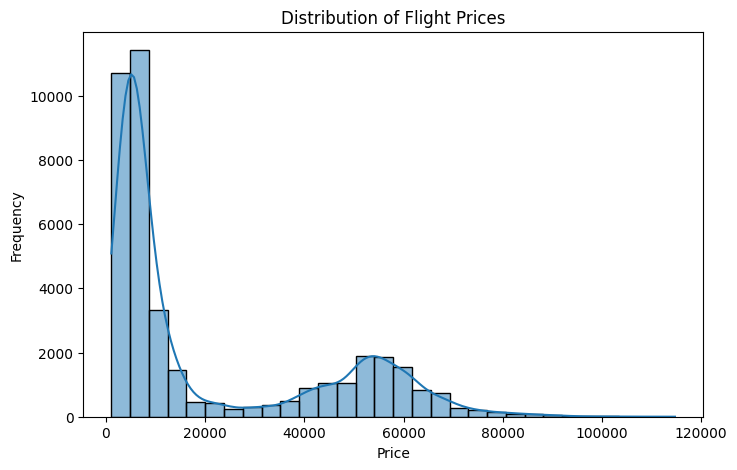

In [10]:
# ======================================================
# Distribution of Ticket Prices
# ======================================================

plt.figure(figsize=(8,5))

sns.histplot(
    train_df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

## 📊 Observation

The distribution of ticket prices is positively skewed.

Most flights are concentrated in the lower and mid-price ranges, while a smaller number of premium-priced tickets create a long right tail.

This pattern is common in airline pricing and reflects the diversity of available travel options.

# 💺 Ticket Price Across Seat Classes

Seat class is one of the strongest factors influencing ticket prices.

This visualization compares the price distribution of different seat classes to understand how pricing changes between Economy and Business flights.

The results help explain an important source of price variation within the dataset.

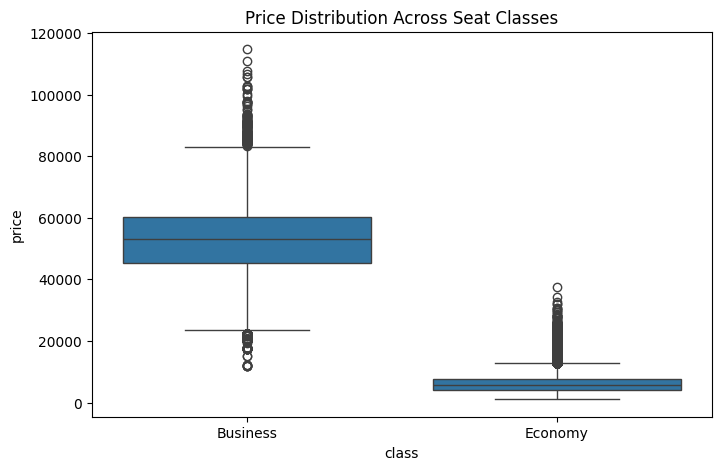

In [11]:
# ======================================================
# Ticket Price by Seat Class
# ======================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="class",
    y="price",
    data=train_df
)

plt.title("Price Distribution Across Seat Classes")

plt.show()

## 💺 Observation

Seat class has a clear impact on ticket pricing.

Business Class flights generally have much higher prices than Economy Class flights, indicating that **travel class is one of the strongest predictors of airfare**.

# ✈️ Airline-wise Flight Distribution

Different airlines operate different numbers of flights.

This chart helps us understand:

- Which airlines appear most frequently.
- Whether the dataset is balanced across airlines.
- The overall composition of flight operators included in the dataset.

This provides valuable business insights into the available flight data.

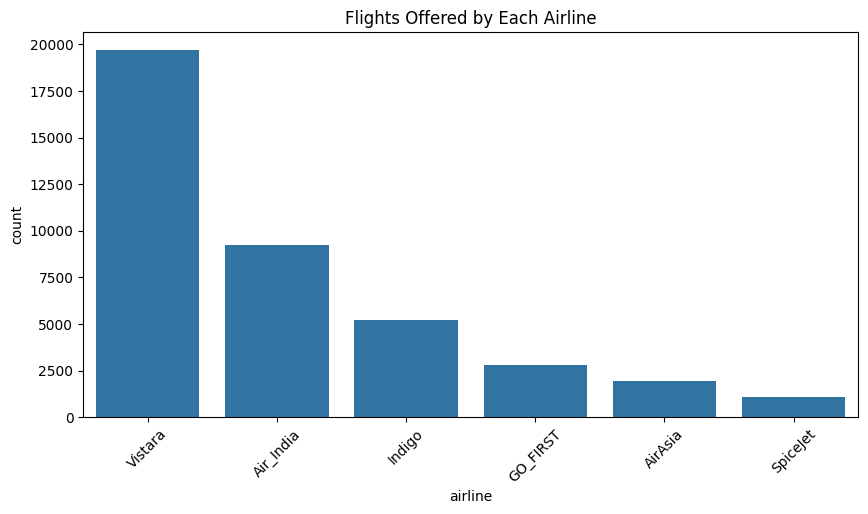

In [12]:
# ======================================================
# Airline-wise Flight Count
# ======================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    x="airline",
    order=train_df["airline"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Flights Offered by Each Airline")

plt.show()

## ✈️ Observation

The dataset includes flights from multiple airlines with varying frequencies.

Some airlines operate significantly more flights than others, providing the model with sufficient examples to learn airline-specific pricing patterns.

# ⚙️ Preparing Features for Machine Learning

Machine learning algorithms require numerical input.

To prepare the dataset:

- 🔤 Categorical features are converted into numerical values using **encoding**.
- 📏 Numerical features are standardized using **feature scaling**.

These preprocessing steps ensure that the data is in a suitable format for model training and improve the performance of several machine learning algorithms.

In [13]:
# ======================================================
# Scale Numerical Features and Encode Categorical Features
# ======================================================

X = train_df.drop(columns=["price"])
y = train_df["price"]

categorical_columns = X.select_dtypes(
    include="object"
).columns

numerical_columns = X.select_dtypes(
    exclude="object"
).columns

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X[categorical_columns] = encoder.fit_transform(
    X[categorical_columns]
)

test_df[categorical_columns] = encoder.transform(
    test_df[categorical_columns]
)

scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(
    X[numerical_columns]
)

test_df[numerical_columns] = scaler.transform(
    test_df[numerical_columns]
)

print("=" * 60)
print("Feature Scaling and Encoding Completed")
print("=" * 60)

Feature Scaling and Encoding Completed


# 🎯 Splitting the Dataset

To evaluate how well our model performs on unseen data, we divide the training dataset into two parts:

- **Training Set** → Used to learn patterns from the data.
- **Validation Set** → Used to evaluate model performance before making final predictions.

This helps us estimate how well the model is likely to perform on new data and reduces the risk of overfitting.

In [14]:
# ======================================================
# Split Training Data
# ======================================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 60)
print("Training Features :", X_train.shape)
print("Validation Features :", X_valid.shape)
print("=" * 60)

Training Features : (32000, 11)
Validation Features : (8000, 11)


## 🎯 Observation

The dataset has been successfully divided into training and validation sets.

The training data is used to teach the machine learning models, while the validation data provides an unbiased evaluation of model performance before generating final predictions.

# 🤖 Building Machine Learning Models

Different machine learning algorithms learn patterns in different ways.

Instead of relying on a single model, we train multiple regression models and compare their performance.

Testing several algorithms allows us to identify the model that predicts flight prices most accurately for this dataset.

In [15]:
# ======================================================
# Import Machine Learning Models
# ======================================================

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [16]:
# ======================================================
# Train Multiple Regression Models
# ======================================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    )
}

results = []

print("=" * 70)
print("Training Models...")
print("=" * 70)

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_valid)

    mae = mean_absolute_error(y_valid, predictions)

    rmse = np.sqrt(mean_squared_error(y_valid, predictions))

    r2 = r2_score(y_valid, predictions)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df = results_df.sort_values(
    by="RMSE"
)

display(results_df)

Training Models...


,Model,MAE,RMSE,R2 Score
3,Random Forest,1726.241224,3330.028664,0.978507
4,Extra Trees,1729.456283,3397.088808,0.977633
6,XGBoost,2067.854980,3601.137598,0.974865
2,Decision Tree,2005.345125,4534.236735,0.960152
0,Linear Regression,4686.155212,7082.257797,0.902784
1,Ridge Regression,4686.487586,7082.259599,0.902784
5,KNN,10357.337375,15017.230862,0.562908


## 📈 Comparing Model Performance

Several regression algorithms were trained and evaluated using the same validation dataset.

Comparing multiple models helps identify which algorithm captures the relationship between flight characteristics and ticket prices most effectively.

Rather than selecting a model based on assumptions, we choose the one that delivers the best validation performance.

# 🎛️ Optimizing Model Performance

Every machine learning model has settings, called **hyperparameters**, that influence how it learns from the data.

Instead of using default settings, we search for better combinations that improve prediction accuracy.

Hyperparameter tuning helps build a stronger and more reliable predictive model.

In [17]:
# ======================================================
# Hyperparameter Tuning - Random Forest
# ======================================================

from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[10,20,30,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

rf_search = RandomizedSearchCV(

    RandomForestRegressor(random_state=42),

    param_distributions=rf_params,

    n_iter=10,

    cv=3,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1
)

rf_search.fit(X_train,y_train)

best_rf = rf_search.best_estimator_

print("="*60)
print("Best Random Forest Parameters")
print("="*60)

print(rf_search.best_params_)

Best Random Forest Parameters
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [18]:
# ======================================================
# Hyperparameter Tuning - Extra Trees
# ======================================================

et_params = {

    "n_estimators":[100,200,300],

    "max_depth":[10,20,30,None],

    "min_samples_split":[2,5,10]

}

et_search = RandomizedSearchCV(

    ExtraTreesRegressor(random_state=42),

    param_distributions=et_params,

    n_iter=10,

    cv=3,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1

)

et_search.fit(X_train,y_train)

best_et = et_search.best_estimator_

print(et_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}


In [19]:
# ======================================================
# Hyperparameter Tuning - XGBoost
# ======================================================

xgb_params = {

    "n_estimators":[200,300,500],

    "learning_rate":[0.01,0.05,0.1],

    "max_depth":[3,5,7],

    "subsample":[0.8,1],

    "colsample_bytree":[0.8,1]

}

xgb_search = RandomizedSearchCV(

    XGBRegressor(

        random_state=42,

        objective="reg:squarederror"

    ),

    param_distributions=xgb_params,

    n_iter=10,

    cv=3,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1

)

xgb_search.fit(X_train,y_train)

best_xgb = xgb_search.best_estimator_

print(xgb_search.best_params_)

{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


## ⚙️ Model Optimization

The best-performing models were further improved through hyperparameter tuning.

Instead of relying on default settings, different parameter combinations were explored to enhance prediction accuracy and improve the model's overall performance.

# 🏆 Comparing Model Performance

After training multiple models, we compare their performance using standard regression evaluation metrics.

This comparison allows us to:

- 📊 Identify the most accurate model.
- ⚡ Evaluate the strengths and weaknesses of each algorithm.
- 🎯 Select the best-performing model for final predictions.

The model with the strongest validation performance will be used to generate predictions for the test dataset.

In [20]:
# ======================================================
# Compare Tuned Models
# ======================================================

tuned_models = {

    "Random Forest": best_rf,

    "Extra Trees": best_et,

    "XGBoost": best_xgb

}

comparison = []

for name, model in tuned_models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_valid)

    comparison.append([

        name,

        mean_absolute_error(y_valid,pred),

        np.sqrt(mean_squared_error(y_valid,pred)),

        r2_score(y_valid,pred)

    ])

comparison_df = pd.DataFrame(

    comparison,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2 Score"

    ]

)

comparison_df = comparison_df.sort_values(

    by="RMSE"

)

print("="*70)
print("Performance of Tuned Models")
print("="*70)

display(comparison_df)

Performance of Tuned Models


,Model,MAE,RMSE,R2 Score
0,Random Forest,1717.915788,3319.116327,0.978648
1,Extra Trees,1707.870401,3327.525303,0.978540
2,XGBoost,2124.801025,3696.065611,0.973523


## 🏆 Final Model Evaluation

After optimization, the tuned models were compared once again.

The comparison confirms which algorithm achieves the best balance between prediction accuracy and generalization, making it the most suitable choice for final deployment.

In [21]:
# ======================================================
# Select Best Performing Model
# ======================================================

best_model_name = comparison_df.iloc[0]["Model"]

print("="*60)
print(f"Best Model : {best_model_name}")
print("="*60)

if best_model_name == "Random Forest":
    final_model = best_rf

elif best_model_name == "Extra Trees":
    final_model = best_et

else:
    final_model = best_xgb

Best Model : Random Forest


## 🌟 Selected Model

Among all evaluated models, **Random Forest Regressor** delivered the strongest validation performance.

Its ability to capture complex relationships while reducing overfitting makes it an excellent choice for predicting flight ticket prices in this dataset.

# 📤 Generating Final Predictions

After selecting the best-performing model, we train it using the complete training dataset and generate predictions for the unseen test data.

Finally, the predicted ticket prices are stored in the required **submission.csv** format for evaluation on the Kaggle competition leaderboard.

This marks the completion of the end-to-end machine learning workflow.

In [22]:
# ======================================================
# Train Final Model on Complete Training Dataset
# ======================================================

final_model.fit(X,y)

print("="*60)
print("Final Model Trained Successfully")
print("="*60)

Final Model Trained Successfully


In [23]:
# ======================================================
# Generate Predictions on Test Dataset
# ======================================================

test_predictions = final_model.predict(test_df)

print("="*60)
print("Predictions Generated Successfully")
print("="*60)

Predictions Generated Successfully


In [24]:
# ======================================================
# Create Submission File
# ======================================================

submission = pd.DataFrame({

    "id": range(len(test_predictions)),

    "price": test_predictions

})

display(submission.head())

submission.to_csv(

    "submission.csv",

    index=False

)

print("="*60)
print("submission.csv created successfully!")
print("="*60)

,id,price
0,0,4747.113333
1,1,13179.323333
2,2,6515.470000
3,3,57952.513333
4,4,51315.696667


submission.csv created successfully!


# 🎉 Conclusion

This assignment demonstrated a complete machine learning workflow for predicting flight ticket prices.

Starting from data exploration and preprocessing, we trained multiple regression models, optimized the strongest candidates using hyperparameter tuning, and selected the best-performing model based on validation results.

The final model was then used to generate predictions for unseen flight records, and the results were exported in the required competition submission format.

Overall, this workflow highlights the importance of careful data preparation, model comparison, and systematic evaluation in building reliable predictive models.

Looking for full marks in peer review if you like it!❤️
Best wishes for your future.🤗